In [ ]:
import ast
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
)

sys.path.append("..")

from config import MAX_K
from src.dataset import create_train_val_datasets

In [13]:
path = Path("evaluation_results_model_triple_head.csv")
results_df = pd.read_csv(path)

In [16]:
LABELS = np.arange(1, MAX_K + 1)

def macro_precision_pm1(y_true, y_pred, labels):
    precisions = []
    for k in labels:
        pred_mask = (y_pred == k)
        
        if np.sum(pred_mask) == 0:
            precisions.append(0.0) 
        else:
            correct_pm1 = np.abs(y_true[pred_mask] - k) <= 1
            precisions.append(np.mean(correct_pm1))
            
    return np.mean(precisions) if precisions else 0.0

def compute_metrics(df, target_col="true_K", pred_col="pred_K"):
    y_true = df[target_col].to_numpy()
    y_pred = df[pred_col].to_numpy()

    return pd.Series({
        "n": len(df),
        "acc": accuracy_score(y_true, y_pred),
        "acc_pm1": np.mean(np.abs(y_true - y_pred) <= 1),
        "precision_pm1_macro": macro_precision_pm1(y_true, y_pred, LABELS),
        "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        "mae": mean_absolute_error(y_true, y_pred),
        "mean_error": np.mean(y_pred - y_true),
    })

metrics_by_run = results_df.groupby('run').apply(compute_metrics)
display(metrics_by_run)

,n,acc,acc_pm1,precision_pm1_macro,macro_f1,mae,mean_error
run,,,,,,,
0,500000.0,0.87209,0.994348,0.994542,0.871578,0.133708,-0.084676


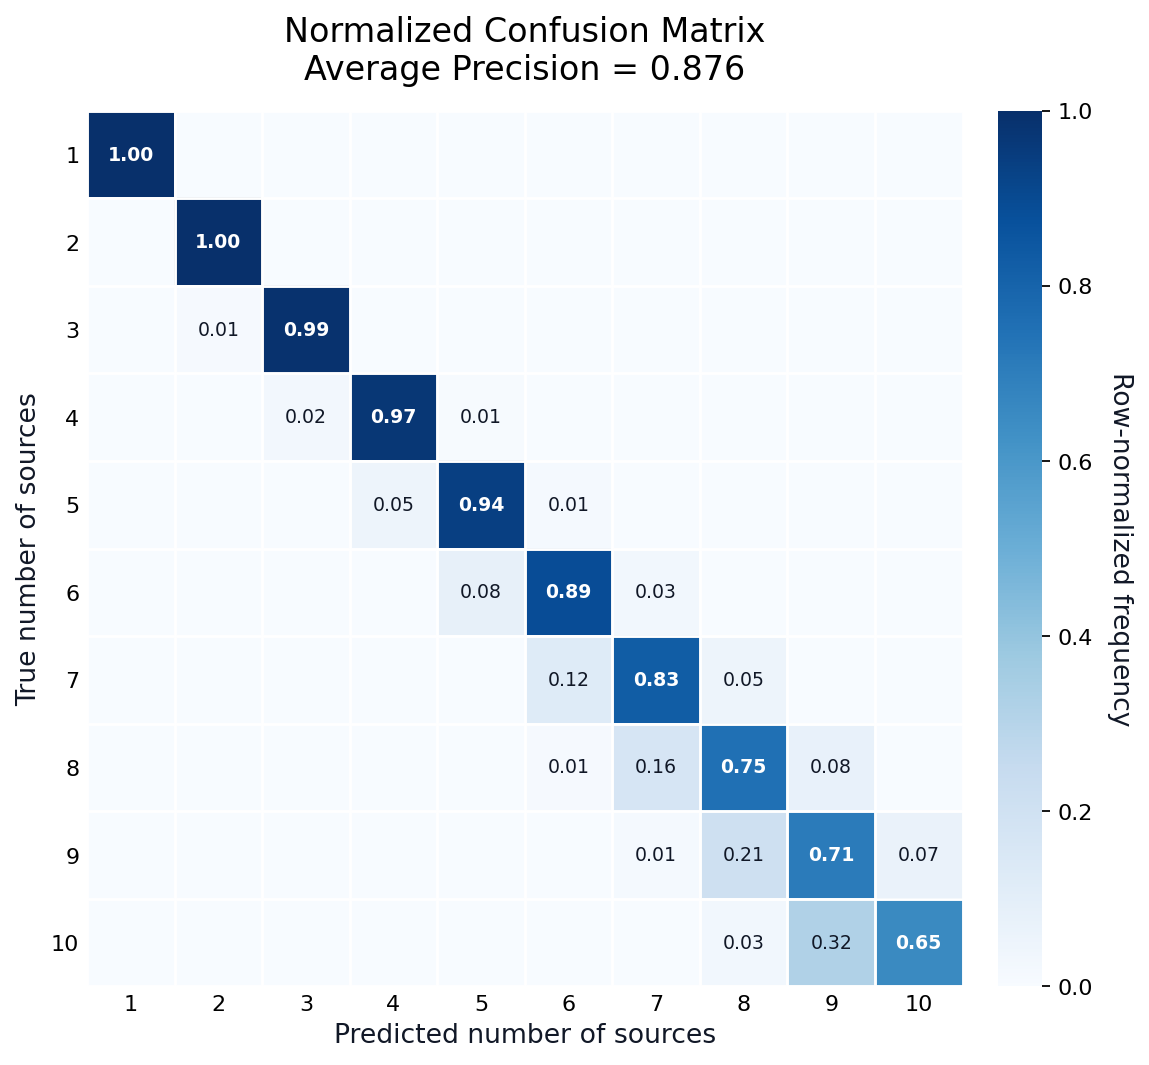

In [17]:
PRED_COL = "pred_K"
cm_df = results_df.copy()


labels = np.arange(1, int(max(cm_df["true_K"].max(), cm_df[PRED_COL].max())) + 1)
cm = confusion_matrix(cm_df["true_K"], cm_df[PRED_COL], labels=labels)
cm_norm = np.divide(
    cm,
    cm.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm, dtype=float),
    where=cm.sum(axis=1, keepdims=True) != 0,
)
accuracy = np.mean(cm_df["true_K"].to_numpy() == cm_df[PRED_COL].to_numpy())
precision_macro = precision_score(cm_df["true_K"], cm_df[PRED_COL], average="macro", zero_division=0)
precision_weighted = precision_score(cm_df["true_K"], cm_df[PRED_COL], average="weighted", zero_division=0)
f1_macro = f1_score(cm_df["true_K"], cm_df[PRED_COL], average="macro", zero_division=0)
f1_weighted = f1_score(cm_df["true_K"], cm_df[PRED_COL], average="weighted", zero_division=0)


with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    # "axes.titleweight": "bold",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}):
    fig, ax = plt.subplots(figsize=(8.4, 7.2), dpi=160)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")

    # ax.set_title(f"Normalized Confusion Matrix\nAverage Accuracy = {accuracy:.3f}\nAverage Precision (Macro) = {precision_macro:.3f}\nAverage Precision (Weighted) = {precision_weighted:.3f}\nAverage F1-Score (Macro) = {f1_macro:.3f}\nAverage F1-Score (Weighted) = {f1_weighted:.3f}", pad=14)
    ax.set_title(f"Normalized Confusion Matrix\nAverage Precision = {precision_macro:.3f}", pad=14)
    ax.set_xlabel("Predicted number of sources")
    ax.set_ylabel("True number of sources")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.3)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            if value < 0.005:
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold" if i == j else "normal",
                color="white" if value > 0.45 else "#111827",
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.035)
    cbar.set_label("Row-normalized frequency", rotation=270, labelpad=18)
    cbar.outline.set_visible(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.subplots_adjust(left=0.12, right=0.88, bottom=0.1, top=0.86)
    plt.show()

Using 449,875/500,000 samples with true_K >= 2; weighted-F1 labels=[2, 3, 4, 5, 6, 7, 8, 9, 10]


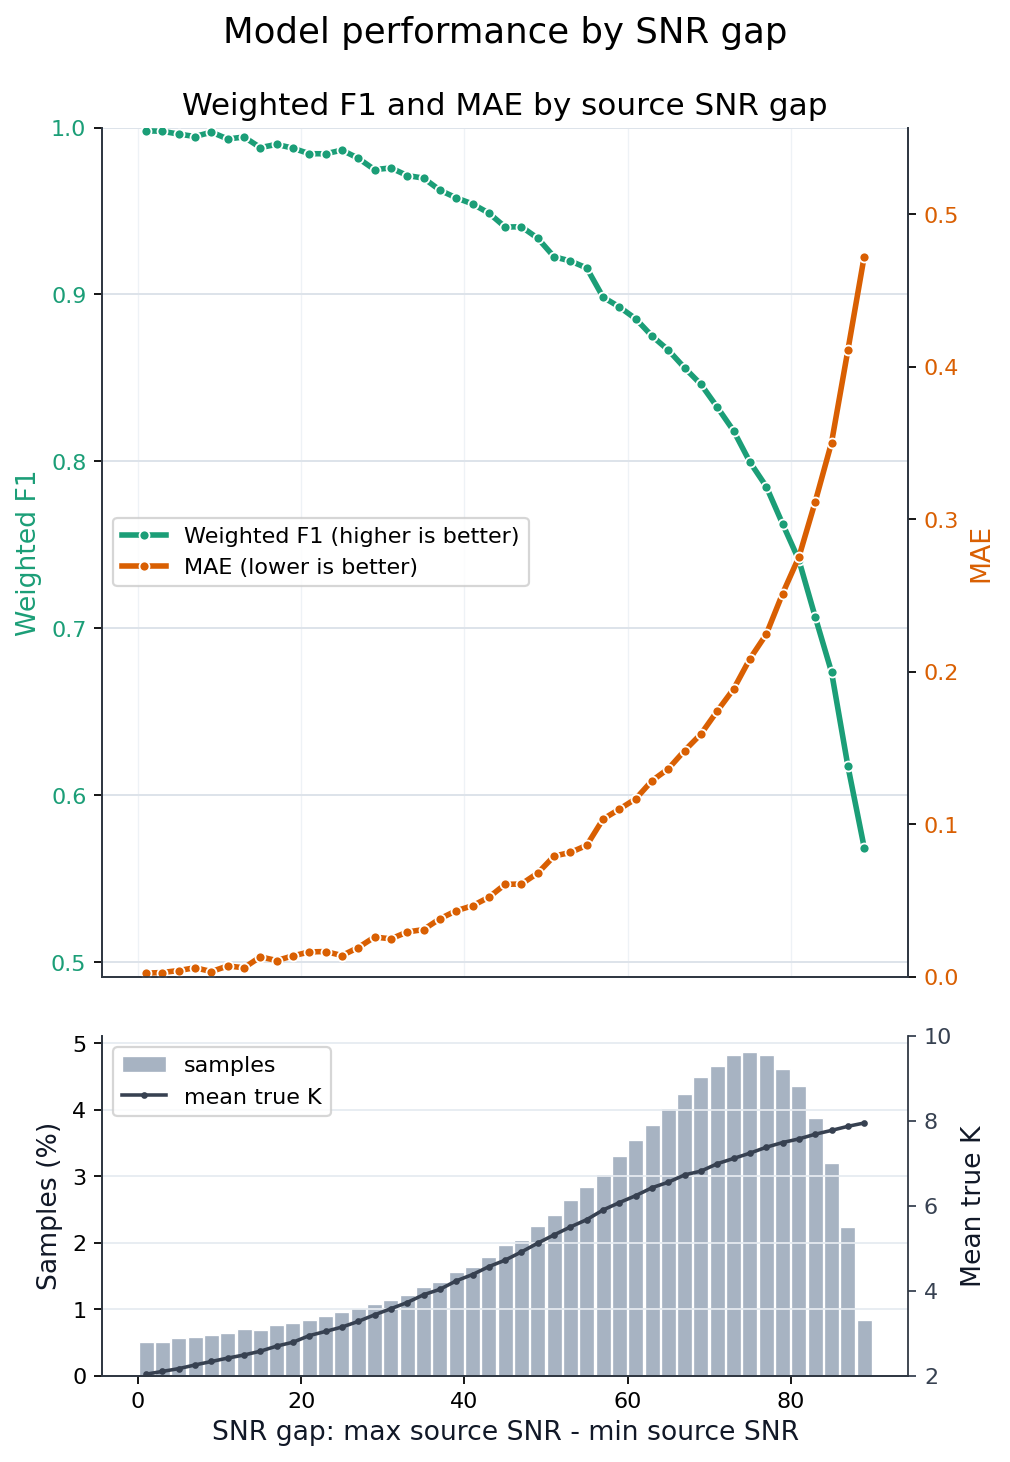

In [18]:
PRED_COL = "pred_K"
MIN_K_FOR_GAP_COMPARISON = 2
N_BINS = 45

snr_df = results_df.copy()

def parse_snr_values(values):
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=float)

snr_df = snr_df.copy()
snr_arrays = snr_df["snr_values"].map(parse_snr_values)
snr_df["snr_gap"] = snr_arrays.map(
    lambda values: float(values.max() - values.min()) if len(values) else np.nan
)
snr_df["true_K"] = snr_df["true_K"].astype(int)
snr_df[PRED_COL] = snr_df[PRED_COL].astype(int)

max_k = int(globals().get("MAX_K", max(snr_df["true_K"].max(), snr_df[PRED_COL].max())))
f1_labels = np.arange(MIN_K_FOR_GAP_COMPARISON, max_k + 1)

valid = np.isfinite(snr_df["snr_gap"]) & (snr_df["true_K"] >= MIN_K_FOR_GAP_COMPARISON)
analysis_df = snr_df.loc[valid].copy()
if analysis_df.empty:
    raise ValueError("No samples left after SNR-gap and K filtering")

print(
    f"Using {len(analysis_df):,}/{len(snr_df):,} samples with "
    f"true_K >= {MIN_K_FOR_GAP_COMPARISON}; weighted-F1 labels={f1_labels.tolist()}"
)

bin_edges = np.linspace(0.0, np.nanmax(analysis_df["snr_gap"]), N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

rows = []
for idx, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    if idx == len(bin_edges) - 2:
        mask = (analysis_df["snr_gap"] >= left) & (analysis_df["snr_gap"] <= right)
    else:
        mask = (analysis_df["snr_gap"] >= left) & (analysis_df["snr_gap"] < right)

    bin_df = analysis_df.loc[mask]
    n = int(len(bin_df))
    if n == 0:
        rows.append({
            "center": bin_centers[idx],
            "left": left,
            "right": right,
            "n": n,
            "sample_pct": 0.0,
            "mean_K": np.nan,
            "weighted_f1": np.nan,
            "mae": np.nan,
        })
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    rows.append({
        "center": bin_centers[idx],
        "left": left,
        "right": right,
        "n": n,
        "sample_pct": 100 * n / len(analysis_df),
        "mean_K": float(np.mean(y_true_bin)),
        "weighted_f1": f1_score(
            y_true_bin,
            y_pred_bin,
            labels=f1_labels,
            average="weighted",
            zero_division=0,
        ),
        "mae": mean_absolute_error(y_true_bin, y_pred_bin),
    })

metric_by_gap = pd.DataFrame(rows)
hist_frequency = metric_by_gap["sample_pct"].to_numpy()

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(6, 10),
        dpi=160,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.1},
    )

    ax_curve = axes[0]
    ax_hist = axes[1]

    # Tracé du F1 Score (Axe gauche)
    color_f1 = "#1B9E77"
    line_f1 = ax_curve.plot(
        metric_by_gap["center"],
        metric_by_gap["weighted_f1"],
        color=color_f1,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="Weighted F1 (higher is better)"
    )
    ax_curve.set_ylabel("Weighted F1", color=color_f1)
    ax_curve.tick_params(axis="y", labelcolor=color_f1)
    ax_curve.grid(axis="y", color="#DDE3EA", linewidth=0.9)
    ax_curve.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    ax_curve.tick_params(axis="x", labelbottom=False, length=0)
    
    # Ajustement de l'axe y gauche
    f1_values = metric_by_gap["weighted_f1"].to_numpy(dtype=float)
    if np.isfinite(f1_values).any():
        y_min = np.nanmin(f1_values)
        y_max = np.nanmax(f1_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_curve.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))

    # Tracé de la MAE (Axe droit)
    ax_mae = ax_curve.twinx()
    color_mae = "#D95F02"
    line_mae = ax_mae.plot(
        metric_by_gap["center"],
        metric_by_gap["mae"],
        color=color_mae,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="MAE (lower is better)"
    )
    ax_mae.set_ylabel("MAE", color=color_mae)
    ax_mae.tick_params(axis="y", labelcolor=color_mae)

    # Ajustement de l'axe y droit
    mae_values = metric_by_gap["mae"].to_numpy(dtype=float)
    if np.isfinite(mae_values).any():
        y_min = np.nanmin(mae_values)
        y_max = np.nanmax(mae_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_mae.set_ylim(max(0.0, y_min - pad), y_max + pad)

    ax_curve.set_title("Weighted F1 and MAE by source SNR gap")

    # Regroupement des légendes
    lines = line_f1 + line_mae
    labels = [l.get_label() for l in lines]
    ax_curve.legend(lines, labels, loc="center left")

    # Histogramme en dessous
    bars = ax_hist.bar(
        bin_centers,
        hist_frequency,
        width=bin_widths * 0.92,
        align="center",
        color="#A7B3C2",
        edgecolor="white",
        linewidth=0.6,
        label="samples",
    )
    ax_hist.set_ylabel("Samples (%)")
    ax_hist.set_xlabel("SNR gap: max source SNR - min source SNR")
    ax_hist.grid(axis="y", color="#E6EBF1", linewidth=0.8)

    ax_k = ax_hist.twinx()
    line_k = ax_k.plot(
        metric_by_gap["center"],
        metric_by_gap["mean_K"],
        color="#374151",
        linewidth=1.6,
        marker=".",
        markersize=4,
        label="mean true K",
    )
    ax_k.set_ylabel("Mean true K")
    ax_k.set_ylim(MIN_K_FOR_GAP_COMPARISON, max_k)
    ax_k.tick_params(axis="y", colors="#374151")
    
    ax_hist.legend([bars, line_k[0]], ["samples", "mean true K"], loc="upper left")

    # Nettoyage des bordures
    ax_curve.spines["top"].set_visible(False)
    ax_mae.spines["top"].set_visible(False)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_k.spines["top"].set_visible(False)

    fig.suptitle(
        "Model performance by SNR gap",
        fontsize=16,
        y=0.95,
    )
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.1, top=0.88, hspace=0.1)
    plt.show()

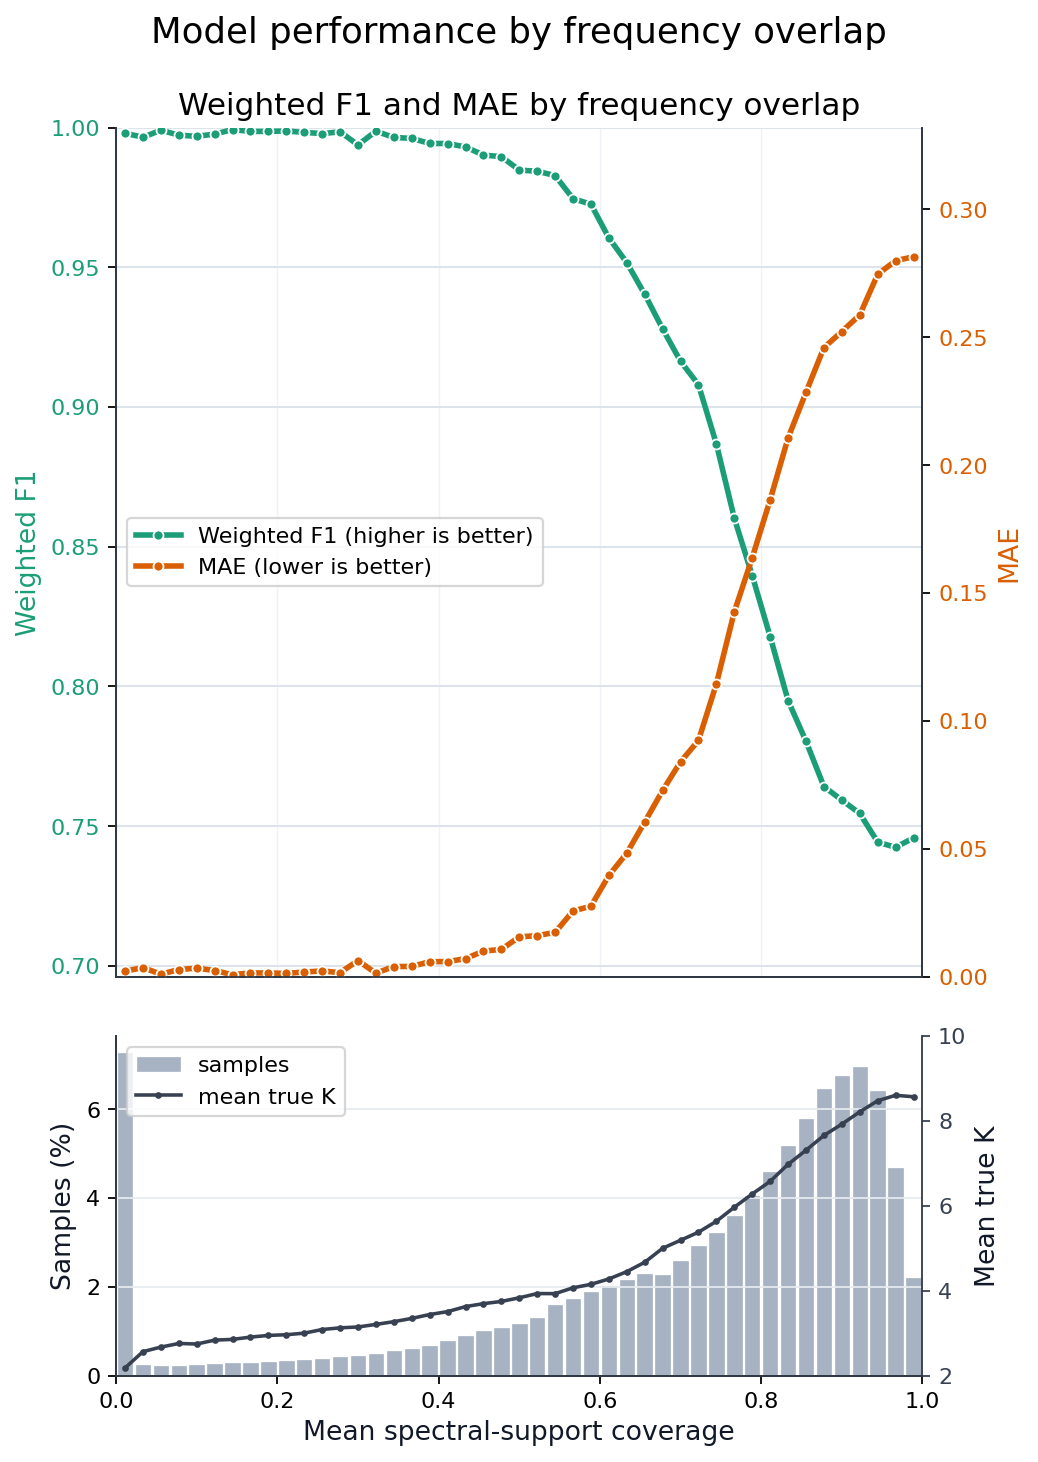

In [28]:
PRED_COL = "pred_K"
MIN_K_FOR_OVERLAP_COMPARISON = 2
N_OVERLAP_BINS = 45


def parse_frequency_bounds(values):
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=int)


def interval_union_length(intervals):
    if not intervals:
        return 0

    intervals = sorted(intervals)
    total = 0
    current_start, current_stop = intervals[0]
    for start, stop in intervals[1:]:
        if start <= current_stop:
            current_stop = max(current_stop, stop)
        else:
            total += current_stop - current_start
            current_start, current_stop = start, stop
    return total + current_stop - current_start


def mean_spectral_support_coverage(starts, stops):
    starts = parse_frequency_bounds(starts)
    stops = parse_frequency_bounds(stops)
    intervals = [
        (int(start), int(stop))
        for start, stop in zip(starts, stops)
        if start >= 0 and stop > start
    ]

    if len(intervals) < 2:
        return 0.0

    coverages = []
    for i, (start, stop) in enumerate(intervals):
        covered_segments = [
            (max(start, other_start), min(stop, other_stop))
            for j, (other_start, other_stop) in enumerate(intervals)
            if i != j and max(start, other_start) < min(stop, other_stop)
        ]
        covered_length = interval_union_length(covered_segments)
        coverages.append(covered_length / (stop - start))

    return float(np.mean(coverages))


overlap_df = results_df.copy()
overlap_df["true_K"] = overlap_df["true_K"].astype(int)
overlap_df[PRED_COL] = overlap_df[PRED_COL].astype(int)
overlap_df["frequency_overlap"] = [
    mean_spectral_support_coverage(starts, stops)
    for starts, stops in zip(overlap_df["freq_bin_start"], overlap_df["freq_bin_stop"])
]

analysis_df = overlap_df.loc[
    (overlap_df["true_K"] >= MIN_K_FOR_OVERLAP_COMPARISON)
    & np.isfinite(overlap_df["frequency_overlap"])
].copy()
if analysis_df.empty:
    raise ValueError("No samples left after frequency-overlap and K filtering")

max_k = int(max(analysis_df["true_K"].max(), analysis_df[PRED_COL].max()))
f1_labels = np.arange(MIN_K_FOR_OVERLAP_COMPARISON, max_k + 1)
bin_edges = np.linspace(0.0, 1.0, N_OVERLAP_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

rows = []
for idx, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    if idx == N_OVERLAP_BINS - 1:
        mask = (analysis_df["frequency_overlap"] >= left) & (analysis_df["frequency_overlap"] <= right)
    else:
        mask = (analysis_df["frequency_overlap"] >= left) & (analysis_df["frequency_overlap"] < right)

    bin_df = analysis_df.loc[mask]
    n = len(bin_df)
    if n == 0:
        rows.append({
            "center": bin_centers[idx],
            "n": 0,
            "sample_pct": 0.0,
            "mean_K": np.nan,
            "weighted_f1": np.nan,
            "mae": np.nan,
        })
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    rows.append({
        "center": bin_centers[idx],
        "n": n,
        "sample_pct": 100 * n / len(analysis_df),
        "mean_K": float(np.mean(y_true_bin)),
        "weighted_f1": f1_score(
            y_true_bin,
            y_pred_bin,
            labels=f1_labels,
            average="weighted",
            zero_division=0,
        ),
        "mae": mean_absolute_error(y_true_bin, y_pred_bin),
    })

metric_by_overlap = pd.DataFrame(rows)

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, (ax_curve, ax_hist) = plt.subplots(
        2,
        1,
        figsize=(6, 10),
        dpi=160,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.1},
    )

    color_f1 = "#1B9E77"
    line_f1 = ax_curve.plot(
        metric_by_overlap["center"],
        metric_by_overlap["weighted_f1"],
        color=color_f1,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="Weighted F1 (higher is better)",
    )
    ax_curve.set_ylabel("Weighted F1", color=color_f1)
    ax_curve.tick_params(axis="y", labelcolor=color_f1)
    ax_curve.tick_params(axis="x", labelbottom=False, length=0)
    ax_curve.grid(axis="y", color="#DDE3EA", linewidth=0.9)
    ax_curve.grid(axis="x", color="#EEF2F6", linewidth=0.6)

    f1_values = metric_by_overlap["weighted_f1"].to_numpy(dtype=float)
    if np.isfinite(f1_values).any():
        y_min, y_max = np.nanmin(f1_values), np.nanmax(f1_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_curve.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))

    ax_mae = ax_curve.twinx()
    color_mae = "#D95F02"
    line_mae = ax_mae.plot(
        metric_by_overlap["center"],
        metric_by_overlap["mae"],
        color=color_mae,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="MAE (lower is better)",
    )
    ax_mae.set_ylabel("MAE", color=color_mae)
    ax_mae.tick_params(axis="y", labelcolor=color_mae)

    mae_values = metric_by_overlap["mae"].to_numpy(dtype=float)
    if np.isfinite(mae_values).any():
        y_min, y_max = np.nanmin(mae_values), np.nanmax(mae_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_mae.set_ylim(max(0.0, y_min - pad), y_max + pad)

    ax_curve.set_title("Weighted F1 and MAE by frequency overlap")
    lines = line_f1 + line_mae
    ax_curve.legend(lines, [line.get_label() for line in lines], loc="center left")

    bars = ax_hist.bar(
        bin_centers,
        metric_by_overlap["sample_pct"],
        width=bin_widths * 0.92,
        align="center",
        color="#A7B3C2",
        edgecolor="white",
        linewidth=0.6,
    )
    ax_hist.set_ylabel("Samples (%)")
    ax_hist.set_xlabel("Mean spectral-support coverage")
    ax_hist.set_xlim(0.0, 1.0)
    ax_hist.grid(axis="y", color="#E6EBF1", linewidth=0.8)

    ax_k = ax_hist.twinx()
    line_k = ax_k.plot(
        metric_by_overlap["center"],
        metric_by_overlap["mean_K"],
        color="#374151",
        linewidth=1.6,
        marker=".",
        markersize=4,
    )
    ax_k.set_ylabel("Mean true K")
    ax_k.set_ylim(MIN_K_FOR_OVERLAP_COMPARISON, max_k)
    ax_k.tick_params(axis="y", colors="#374151")
    ax_hist.legend([bars, line_k[0]], ["samples", "mean true K"], loc="upper left")

    ax_curve.spines["top"].set_visible(False)
    ax_mae.spines["top"].set_visible(False)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_k.spines["top"].set_visible(False)

    fig.suptitle("Model performance by frequency overlap", fontsize=16, y=0.95)
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.1, top=0.88, hspace=0.1)
    plt.show()

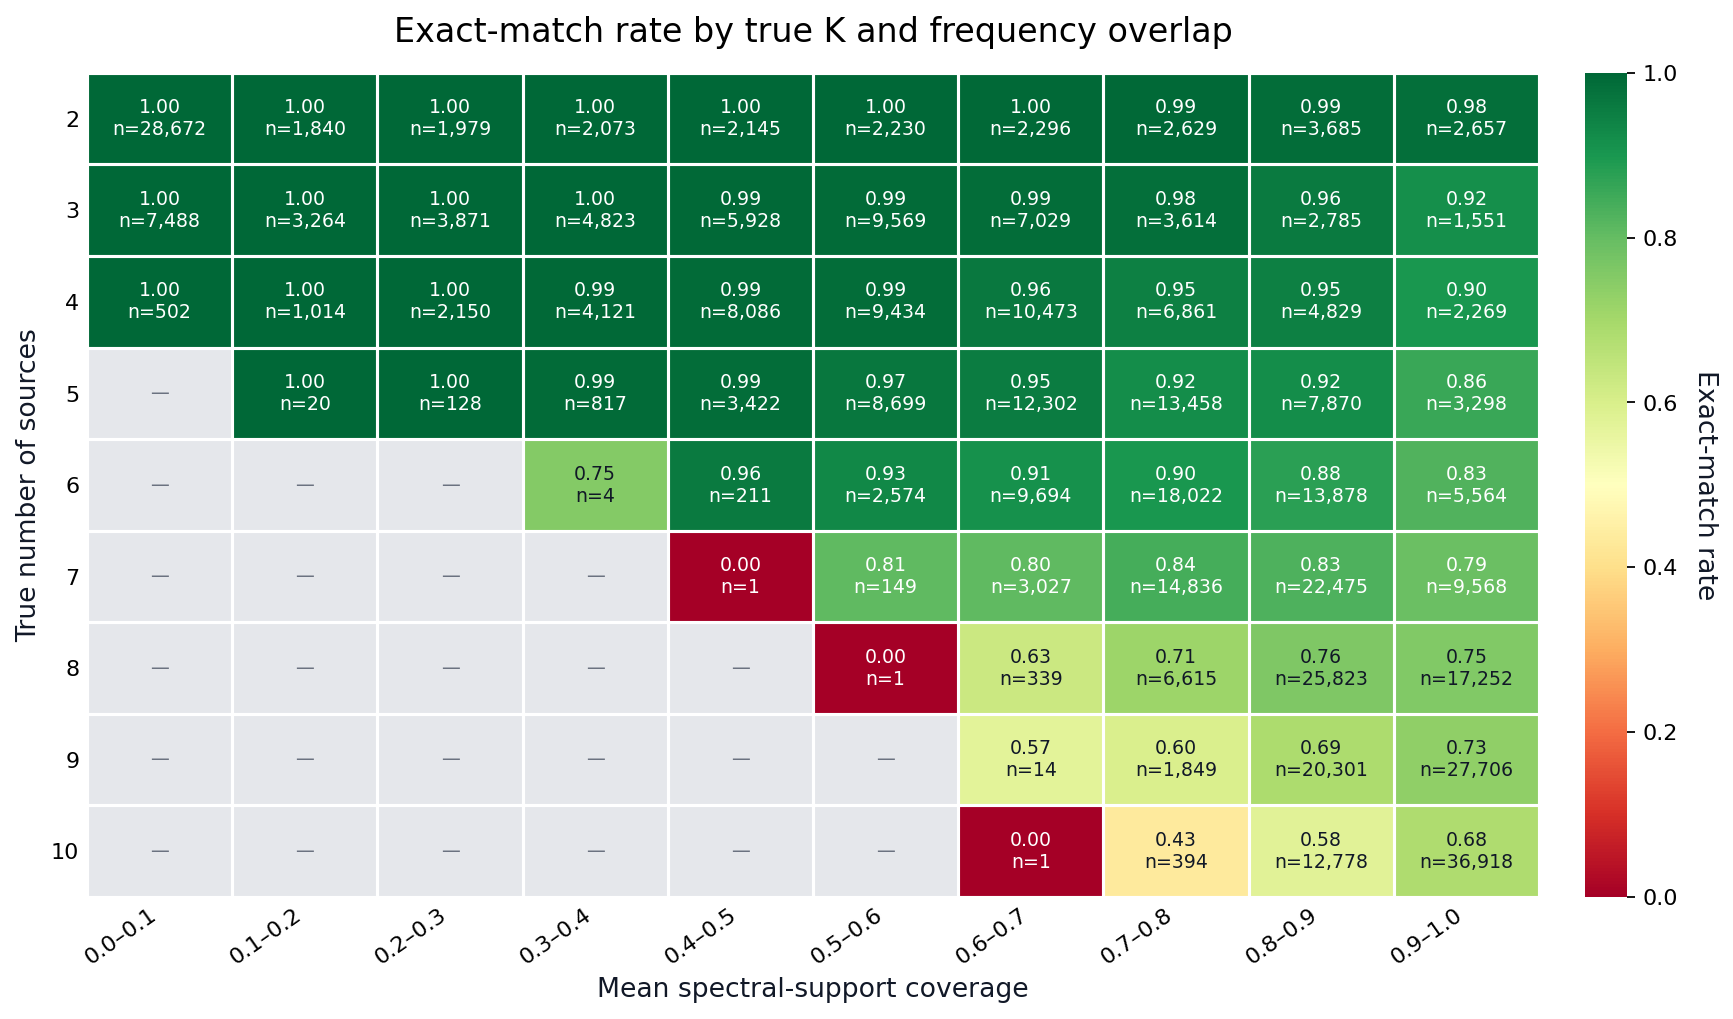

In [30]:
N_OVERLAP_HEATMAP_BINS = 10

heatmap_df = analysis_df.copy()
k_values = np.sort(heatmap_df["true_K"].unique())
heatmap_edges = np.linspace(0.0, 1.0, N_OVERLAP_HEATMAP_BINS + 1)
heatmap_labels = [
    f"{left:.1f}–{right:.1f}"
    for left, right in zip(heatmap_edges[:-1], heatmap_edges[1:])
]

exact_match_matrix = np.full(
    (len(k_values), N_OVERLAP_HEATMAP_BINS), np.nan
)
count_matrix = np.zeros(
    (len(k_values), N_OVERLAP_HEATMAP_BINS), dtype=int
)

for row_idx, k in enumerate(k_values):
    k_df = heatmap_df.loc[heatmap_df["true_K"] == k]
    for col_idx, (left, right) in enumerate(
        zip(heatmap_edges[:-1], heatmap_edges[1:])
    ):
        if col_idx == N_OVERLAP_HEATMAP_BINS - 1:
            mask = (k_df["frequency_overlap"] >= left) & (k_df["frequency_overlap"] <= right)
        else:
            mask = (k_df["frequency_overlap"] >= left) & (k_df["frequency_overlap"] < right)

        bin_df = k_df.loc[mask]
        count_matrix[row_idx, col_idx] = len(bin_df)
        if len(bin_df):
            exact_match_matrix[row_idx, col_idx] = np.mean(
                bin_df[PRED_COL].to_numpy() == bin_df["true_K"].to_numpy()
            )

cmap = plt.colormaps["RdYlGn"].copy()
cmap.set_bad("#E5E7EB")

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}):
    fig, ax = plt.subplots(figsize=(11, 6.5), dpi=160)
    im = ax.imshow(
        exact_match_matrix,
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_title("Exact-match rate by true K and frequency overlap", pad=14)
    ax.set_xlabel("Mean spectral-support coverage")
    ax.set_ylabel("True number of sources")
    ax.set_xticks(np.arange(N_OVERLAP_HEATMAP_BINS))
    ax.set_xticklabels(heatmap_labels, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(k_values)))
    ax.set_yticklabels(k_values)
    ax.set_xticks(np.arange(-0.5, N_OVERLAP_HEATMAP_BINS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(k_values), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.4)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for row_idx in range(len(k_values)):
        for col_idx in range(N_OVERLAP_HEATMAP_BINS):
            value = exact_match_matrix[row_idx, col_idx]
            n = count_matrix[row_idx, col_idx]
            if np.isfinite(value):
                label = f"{value:.2f}\nn={n:,}"
                color = "white" if value < 0.28 or value > 0.78 else "#111827"
            else:
                label = "—"
                color = "#6B7280"
            ax.text(
                col_idx, row_idx, label,
                ha="center", va="center",
                color=color, fontsize=8.5,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Exact-match rate", rotation=270, labelpad=18)
    cbar.outline.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()
    plt.show()